1)	Impor Library & Set Seed

In [4]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [1]:
import torch
import numpy as np
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Subset




2)	Impor & Cek Dataset

In [2]:
data_dir = r"D:/COOLYEAH/SEMESTER 6/DEEP LEARNING CITRA MEDIS/DATA"

In [3]:
import os

print(os.listdir( r"D:/COOLYEAH/SEMESTER 6/DEEP LEARNING CITRA MEDIS/DATA"))

['glioma', 'meningioma', 'notumor', 'pituitary']


3)	Exploratory Data Analysis (EDA)

In [4]:
dataset_eda = datasets.ImageFolder(
    root=data_dir,
    transform=None
)

In [5]:
targets_eda = dataset_eda.targets

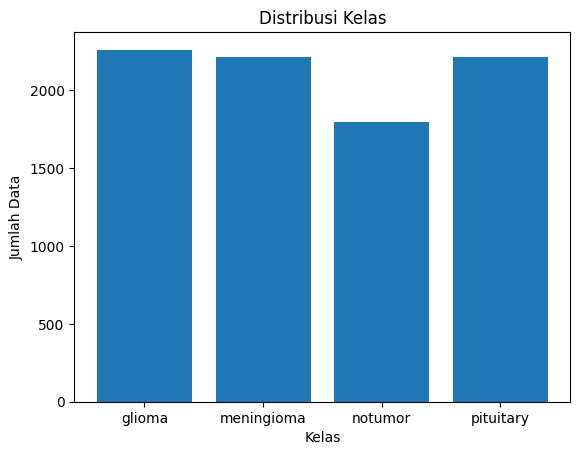

In [6]:
class_counts = np.bincount(targets_eda)
class_names = dataset_eda.classes

plt.bar(class_names, class_counts)
plt.title("Distribusi Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.show()

C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


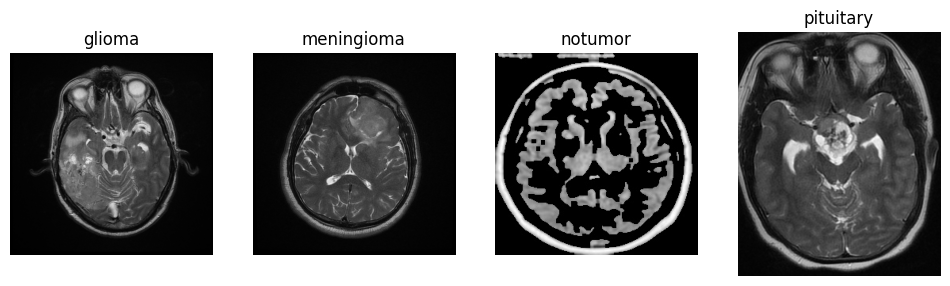

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(12,4))

shown = set()
i = 0

for idx in range(len(dataset_eda)):
    img, label = dataset_eda[idx]

    if label not in shown:
        axes[i].imshow(img)  
        axes[i].set_title(class_names[label])
        axes[i].axis('off')

        shown.add(label)
        i += 1

    if i == 4:
        break

plt.show()

4)	Preprocessing & Augmentasi

In [8]:
def noise_reduction(img):
    import cv2
    import numpy as np
    from PIL import Image

    img = np.array(img)

    denoised = cv2.fastNlMeansDenoisingColored(
        img, None, 10, 10, 7, 21
    )

    return Image.fromarray(denoised)

In [9]:
def contrast_enhancement(img):
    import cv2
    import numpy as np
    from PIL import Image

    img = np.array(img)

    # ubah ke LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))

    enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    return Image.fromarray(enhanced)

In [10]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Lambda(
        lambda img: noise_reduction(img)
    ),

    transforms.Lambda(
        lambda img: contrast_enhancement(img)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: noise_reduction(img)),
    transforms.Lambda(lambda img: contrast_enhancement(img)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

5)	Splitting Data

In [12]:
dataset_train = datasets.ImageFolder(root=data_dir, transform=transform)
dataset_valtest = datasets.ImageFolder(root=data_dir, transform=val_transform)
targets = dataset_train.targets

In [13]:
train_idx, temp_idx = train_test_split(
    range(len(targets)),
    test_size=0.3,
    stratify=targets,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.33,
    stratify=[targets[i] for i in temp_idx],
    random_state=42
)


train_dataset = Subset(dataset_train,   train_idx)
val_dataset   = Subset(dataset_valtest, val_idx)
test_dataset  = Subset(dataset_valtest, test_idx)


6)	Buat DataLoader

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [19]:
class_counts = np.bincount(targets)
print("Class distribution:", class_counts)

Class distribution: [2259 2214 1796 2214]


7)	Inisialisasi Model

In [20]:
model = models.resnet18(pretrained=True)

# ===== FREEZE semua layer dulu =====
for param in model.parameters():
    param.requires_grad = False

# ===== UNFREEZE layer3, layer4, dan fc (2-3 layer terakhir) =====
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

# Ganti fc layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)
# fc layer baru otomatis requires_grad=True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Cek layer yang dilatih
print("Layer yang di-train:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}")

Layer yang di-train:
  layer3.0.conv1.weight
  layer3.0.bn1.weight
  layer3.0.bn1.bias
  layer3.0.conv2.weight
  layer3.0.bn2.weight
  layer3.0.bn2.bias
  layer3.0.downsample.0.weight
  layer3.0.downsample.1.weight
  layer3.0.downsample.1.bias
  layer3.1.conv1.weight
  layer3.1.bn1.weight
  layer3.1.bn1.bias
  layer3.1.conv2.weight
  layer3.1.bn2.weight
  layer3.1.bn2.bias
  layer4.0.conv1.weight
  layer4.0.bn1.weight
  layer4.0.bn1.bias
  layer4.0.conv2.weight
  layer4.0.bn2.weight
  layer4.0.bn2.bias
  layer4.0.downsample.0.weight
  layer4.0.downsample.1.weight
  layer4.0.downsample.1.bias
  layer4.1.conv1.weight
  layer4.1.bn1.weight
  layer4.1.bn1.bias
  layer4.1.conv2.weight
  layer4.1.bn2.weight
  layer4.1.bn2.bias
  fc.weight
  fc.bias


8)	Set Loss, Optimizer, dan Scheduler

In [21]:
class_counts = np.array([2259, 2214, 1796, 2214])

class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()

class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)


In [22]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

9)	Training dan Validation

In [23]:
# ===== INIT EARLY STOPPING =====
best_val_acc = 0
patience = 3
counter = 0

epochs = 10

for epoch in range(epochs):

    # ===== TRAINING =====
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    # ===== PRINT =====
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    # ===== SCHEDULER STEP =====
    scheduler.step()

    # ===== EARLY STOPPING =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")
        print("Ada peningkatan peforma")

    else:
        counter += 1
        print(f"Tidak ada peningkatan peforma({counter}/{patience})")

        if counter >= patience:
            print("🛑 Stop training")
            break

C:\Users\shifa\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 1/10
Train Loss: 0.5264
Validation Accuracy: 86.28%
Ada peningkatan peforma

Epoch 2/10
Train Loss: 0.3004
Validation Accuracy: 89.74%
Ada peningkatan peforma

Epoch 3/10
Train Loss: 0.1991
Validation Accuracy: 92.55%
Ada peningkatan peforma

Epoch 4/10
Train Loss: 0.1270
Validation Accuracy: 93.49%
Ada peningkatan peforma

Epoch 5/10
Train Loss: 0.0959
Validation Accuracy: 94.25%
Ada peningkatan peforma

Epoch 6/10
Train Loss: 0.0840
Validation Accuracy: 94.19%
Tidak ada peningkatan peforma(1/3)

Epoch 7/10
Train Loss: 0.0686
Validation Accuracy: 94.02%
Tidak ada peningkatan peforma(2/3)

Epoch 8/10
Train Loss: 0.0717
Validation Accuracy: 94.19%
Tidak ada peningkatan peforma(3/3)
🛑 Stop training


10)	Testing dan Model

In [ ]:
model.eval()

correct = 0
total = 0

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

accuracy = 100 * correct / total

print("Accuracy:", accuracy)

# ==========================
# Confusion Matrix
# ==========================

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)

# ==========================
# Precision Recall F1-score
# ==========================

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# ==========================
# MSE dan RMSE (opsional)
# ==========================

mse = np.mean((np.array(all_labels) - np.array(all_preds))**2)
rmse = np.sqrt(mse)

print("\nMSE:", mse)
print("RMSE:", rmse)

Accuracy: 96.66666666666667

Confusion Matrix:
[[216   5   2   1]
 [ 11 202   2   4]
 [  1   0 177   0]
 [  1   1   0 217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       224
           1       0.97      0.92      0.95       219
           2       0.98      0.99      0.99       178
           3       0.98      0.99      0.98       219

    accuracy                           0.97       840
   macro avg       0.97      0.97      0.97       840
weighted avg       0.97      0.97      0.97       840


MSE: 0.08095238095238096
RMSE: 0.2845213189769458


11) Menyimpan Model

In [ ]:
torch.save(model.state_dict(),"brain_tumor_resnet18_freeze.pth")

print("Model saved!")

Model saved!


12) Visualisasi Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

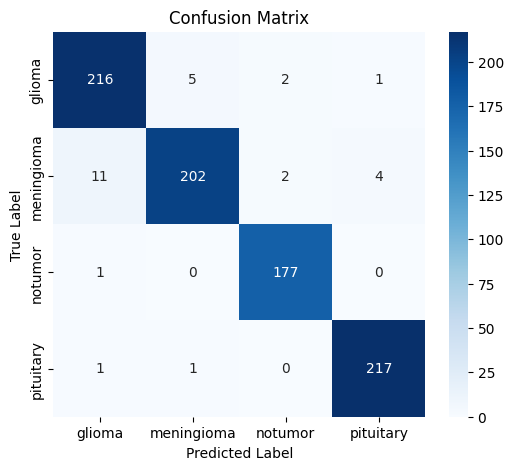

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# hitung confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# nama kelas
class_names = dataset.classes

# plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")